# Spots configuration gallery

A gallery of `add_spots` configurations on an icosphere mesh. All panels share a single temperature colorbar and a fixed camera view; spot longitudes are placed in the visible hemisphere (lon in [-120, +60] for the default view) so every feature is readable. Each mesh subplot draws no axes and no pane background.

In [11]:
import sys
sys.path.append('../../../src')

from spice.models import IcosphereModel
from spice.models.spots import add_spots
from spice.models.utils import lat_to_theta, lon_to_phi

import jax.numpy as jnp
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import art3d

%matplotlib inline

## Base mesh

Single-parameter mesh (effective temperature only) so the colorbar maps directly to spot temperature contrast.

In [12]:
T_BASE = 5800.0   # K, photospheric temperature
T_DELTA = 1500.0  # K, default spot contrast magnitude

base_mesh = IcosphereModel.construct(
    n_vertices=2000,
    radius=1.0,
    mass=1.0,
    parameters=jnp.array([T_BASE]),
    parameter_names=['teff'],
    override_log_g=False,
)

[spice] IcosphereModel constructed in 0.4 s


## Spot configurations

Each entry is a self-contained recipe passed to `add_spots`. Latitudes/longitudes are in degrees and converted with `lat_to_theta` / `lon_to_phi`; spot radii are angular (degrees); temperature deltas are in Kelvin (negative = cool spot, positive = hot spot).

In [13]:
def make_spotted_mesh(mesh, lats, lons, radii, deltas, smoothness):
    return add_spots(
        mesh,
        spot_center_thetas=jnp.array([lat_to_theta(l) for l in lats]),
        spot_center_phis=jnp.array([lon_to_phi(l) for l in lons]),
        spot_radii=jnp.array(radii, dtype=float),
        parameter_deltas=jnp.array(deltas, dtype=float),
        parameter_indices=jnp.zeros(len(lats), dtype=int),
        smoothness=jnp.array(smoothness, dtype=float),
    )


# Visible-hemisphere centre for the default view sits near lon=-30 deg;
# every configuration below keeps spot longitudes in roughly [-120, +60].
VC = 0

configurations = [
    {
        'title': 'a) Penumbra (overlap)',
        'lats': [20.0, 20.0],
        'lons': [VC, VC],
        'radii': [35.0, 14.0],
        'deltas': [-0.5 * T_DELTA, -0.5 * T_DELTA],
        'smoothness': [0.85, 0.0],
    },
    {
        'title': 'b) Hot ring, cool centre',
        # Sharp outer hot spot + smaller cool spot at the same centre. Because
        # add_spots is additive, the inner delta of -2 T_DELTA cancels the
        # +T_DELTA outer contribution and leaves a net -T_DELTA core, with the
        # surrounding annulus glowing at +T_DELTA.
        'lats': [0.0, 0.0],
        'lons': [VC, VC],
        'radii': [30.0, 12.0],
        'deltas': [+T_DELTA, -2.0 * T_DELTA],
        'smoothness': [0.15, 0.0],
    },
    {
        'title': 'c) Graded temperatures',
        # Four well-separated spots spanning the cool-to-hot contrast range.
        'lats': [30.0, -10.0, -30.0, 25.0],
        'lons': [VC - 55.0, VC - 15.0, VC + 25.0, VC + 50.0],
        'radii': [13.0, 13.0, 13.0, 13.0],
        'deltas': [+T_DELTA, +0.4 * T_DELTA, -0.4 * T_DELTA, -T_DELTA],
        'smoothness': [0.15, 0.15, 0.15, 0.15],
    },
    {
        'title': 'd) Mixed-contrast scatter',
        'lats': [40.0, 10.0, -25.0, -50.0, 25.0, -5.0],
        'lons': [VC - 60.0, VC - 20.0, VC + 30.0, VC - 40.0, VC + 40.0, VC],
        'radii': [10.0, 14.0, 9.0, 12.0, 11.0, 8.0],
        'deltas': [+T_DELTA, -T_DELTA, +0.6 * T_DELTA, -T_DELTA, -0.6 * T_DELTA, +T_DELTA],
        'smoothness': [0.4, 0.0, 0.6, 0.2, 0.5, 0.0],
    },
]

spotted_meshes = [make_spotted_mesh(base_mesh, **{k: v for k, v in cfg.items() if k != 'title'})
                  for cfg in configurations]

## Render the gallery

All panels share a single diverging `Normalize` centred on `T_BASE` so cool spots (blue) and hot spots (red) are immediately distinguishable. Each 3D axes has its panes, grid, and tick marks hidden, and uses a fixed camera so the visible hemisphere is the same in every panel.

In [14]:
import cmasher as cm

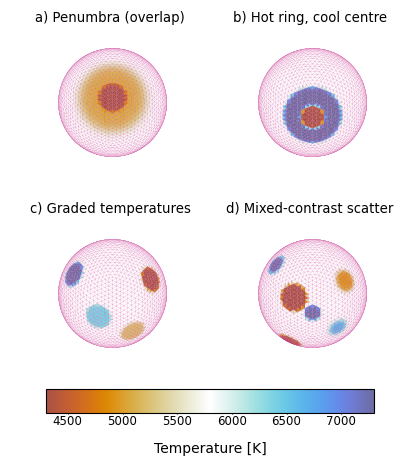

In [18]:
# Parameters to control space between rows and adjust total figure height
ROW_SPACING = 0.0              # vertical space between panels, default ultra-compact
HEIGHT_PER_ROW = 2             # height per row in inches
CBAR_HEIGHT_RATIO = 0.1      # height ratio for colorbar row

CMAP = 'cmr.prinsenvlag'
VIEW = dict(elev=15, azim=0)
all_temps = np.concatenate([m.parameters[:, 0] for m in spotted_meshes])
# Diverging norm anchored at T_BASE so the cmap midpoint sits on the photosphere,
# while the ends track the actual data range (avoids a half-empty colorbar when
# the cool/hot extremes are asymmetric).
norm = mpl.colors.TwoSlopeNorm(
    vcenter=T_BASE,
    vmin=float(all_temps.min()),
    vmax=float(all_temps.max()),
)
cmap = mpl.colormaps[CMAP]

def strip_axes(ax):
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor('none')
    ax.grid(False)
    ax.set_axis_off()
    ax.set_facecolor('none')

def draw_mesh(ax, mesh):
    poly = art3d.Poly3DCollection(
        np.asarray(mesh.mesh_elements),
        facecolors=cmap(norm(np.asarray(mesh.parameters[:, 0]))),
        edgecolor='mediumvioletred', linewidths=0.05)
    poly.set_rasterized(True)         # <-- key line
    ax.add_collection(poly)
    lim = 1.05 * float(mesh.radius)
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), zlim=(-lim, lim))
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(**VIEW)

n_cols = 2
n_rows = -(-len(configurations) // n_cols)  # ceiling division

fig = plt.figure(figsize=(2 * n_cols, HEIGHT_PER_ROW * n_rows + 0.01))
gs = fig.add_gridspec(
    n_rows + 1, n_cols,
    height_ratios=[1]*n_rows + [CBAR_HEIGHT_RATIO],   # adjustable colorbar row height
    wspace=0, hspace=ROW_SPACING)                     # user-tunable spacing between tiles

for i, (cfg, mesh) in enumerate(zip(configurations, spotted_meshes)):
    r, c = divmod(i, n_cols)
    ax = fig.add_subplot(gs[r, c], projection='3d')
    strip_axes(ax)
    draw_mesh(ax, mesh)
    # Place titles right above the axes, but with minimal vertical distance.
    # Just reduce the space, but titles are above plots by default.
    ax.set_title(cfg['title'], fontsize=9.5, pad=0.01, y=1.02)

# Add a minimal, thick, short colorbar—just enough for the ticks, but no frame/padding
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
cax = fig.add_subplot(gs[-1, :])
cax.axis("off")

# (x, y, width, height) in cax-axes coordinates
# y=-0.125 + height=1.25 keeps the colorbar centred on cax with 25% overhang
inset_ax = cax.inset_axes([0.5 - 0.82/2, -0.125, 0.82, 1.25])

cbar = fig.colorbar(
    mpl.cm.ScalarMappable(cmap=cmap, norm=norm),
    cax=inset_ax,
    orientation='horizontal'
)

cbar = fig.colorbar(
    mpl.cm.ScalarMappable(cmap=cmap, norm=norm),
    cax=inset_ax,
    orientation='horizontal'
)
cbar.set_label('Temperature [K]', fontsize=10, labelpad=10)  # was 0.5
cbar.ax.tick_params(length=1, labelsize=8.5, pad=0.5)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)  # absolutely no margins
fig.savefig('spots_configurations.pdf', bbox_inches='tight', dpi=300)
plt.show()